# 05 - Kalman filtering and the NIS consistency test

**Goal.** Build the independent, model-based check that catches a perception failure
even when the network is confident. We derive the Kalman filter as recursive
Bayesian estimation, establish the *whiteness* of its innovations, prove that the
normalised innovation squared (NIS) is chi-squared distributed, and use that to test
consistency and detect faults. This is the mathematical core of the whole project.

## 1. Recursive Bayesian estimation

Consider a linear-Gaussian state-space model

$$ x_k = A x_{k-1} + B u_{k-1} + w_{k-1},\quad w\sim\mathcal N(0,Q); \qquad
   y_k = C x_k + v_k,\quad v\sim\mathcal N(0,R). $$

The goal is the posterior $p(x_k\mid y_{1:k})$. It obeys a two-step recursion [2,4]:

**Predict (Chapman-Kolmogorov):**
$$ p(x_k\mid y_{1:k-1}) = \int p(x_k\mid x_{k-1})\,p(x_{k-1}\mid y_{1:k-1})\,\mathrm d x_{k-1}. $$

**Update (Bayes):**
$$ p(x_k\mid y_{1:k}) \propto p(y_k\mid x_k)\,p(x_k\mid y_{1:k-1}). $$

For a linear-Gaussian model every distribution here stays Gaussian, so the whole
recursion collapses to propagating a **mean and covariance** - and that is exactly
the Kalman filter [1].

## 2. The Kalman filter

Writing the Gaussians as $(\hat x, P)$, the recursion becomes:

**Time update (predict)**
$$ \hat x_{k\mid k-1}=A\hat x_{k-1}+Bu_{k-1},\qquad P_{k\mid k-1}=A P_{k-1}A^\top+Q. $$

**Measurement update**
$$ \nu_k = y_k - C\hat x_{k\mid k-1},\qquad S_k = C P_{k\mid k-1}C^\top + R, $$
$$ K_k = P_{k\mid k-1}C^\top S_k^{-1},\qquad
   \hat x_k = \hat x_{k\mid k-1}+K_k\nu_k,\qquad
   P_k = (I-K_kC)P_{k\mid k-1}. $$

The gain $K_k$ can be derived two ways that give the same answer [2,3]: as the
**Bayesian** posterior mean of a Gaussian, or - without any Gaussian assumption - as
the **best linear unbiased estimator** (minimum-variance) that minimises
$\mathbb E\|x_k-\hat x_k\|^2$. Either way, $K_k=P_{k\mid k-1}C^\top S_k^{-1}$.

## 3. The innovation and why it is white

The **innovation** $\nu_k = y_k - C\hat x_{k\mid k-1}$ is the part of the new
measurement that the model did not predict. For the correct model with the optimal
gain it has three properties [5,6]:

$$ \mathbb E[\nu_k]=0,\qquad \mathrm{Cov}[\nu_k]=S_k,\qquad
   \mathbb E[\nu_k\,\nu_j^\top]=0\ \text{ for } k\neq j. $$

The last one - **whiteness** - is the powerful part: an optimal filter extracts *all*
the predictable information, so what remains is temporally uncorrelated noise. The
filter effectively transforms the correlated measurements into a white innovations
sequence (the "innovations representation" [5]). If the innovations are *not* white,
or not zero-mean, or do not match $S_k$, the model is wrong. That is the hook for
both consistency testing and fault detection.

## 4. The NIS statistic and the consistency test

Since $\nu_k\sim\mathcal N(0,S_k)$, whiten it: $e_k=S_k^{-1/2}\nu_k\sim\mathcal N(0,I_m)$.
Then the **normalised innovation squared**

$$ \boxed{\;\mathrm{NIS}_k=\nu_k^\top S_k^{-1}\nu_k = e_k^\top e_k\;}
   \;\sim\;\chi^2_m,\qquad m=\dim(y),\quad \mathbb E[\mathrm{NIS}_k]=m. $$

**Single-sample gate.** $\mathrm{NIS}_k>\chi^2_{m,1-\alpha}$ flags an inconsistent
sample; for $m=2$, $\chi^2_{2,0.99}=9.21$.

**Time-averaged test.** A single sample is noisy. Averaging over a window of $N$
(approximately independent) steps, $\sum_k\mathrm{NIS}_k\sim\chi^2_{Nm}$, so the mean
$\overline{\mathrm{NIS}}$ should fall inside a tight two-sided interval around $m$ -
the **filter consistency test** of Bar-Shalom [6]. Too high means the filter is
*overconfident* (real errors exceed the claimed $S$); too low means it is
*conservative*.

**NEES (a simulation-only cousin).** When the true state is known (as in a
simulator) the normalised estimation error squared
$\mathrm{NEES}_k=(x_k-\hat x_k)^\top P_k^{-1}(x_k-\hat x_k)\sim\chi^2_n$ tests whether
the reported covariance $P_k$ is honest [6]. We use it below to validate our filter.

In [1]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)
L, Ts, V = 2.7, 0.05, 15.0
A = np.array([[1, V*Ts], [0, 1.0]]); B = np.array([0.0, V*Ts/L]); C = np.eye(2)
Qt = np.diag([2e-4, 1e-4])                 # true process-noise covariance
Rt = np.diag([0.02**2, 0.01**2])           # true measurement-noise covariance

def run_filter(N=500, bias_after=None, bias=(0.0, 0.0), R_scale=1.0, seed=0):
    r = np.random.default_rng(seed)
    x = np.zeros(2); xhat = np.zeros(2); P = np.diag([0.05, 0.02])
    Rc = Rt*R_scale                        # covariance the filter *claims* (may be wrong)
    out = {k: [] for k in ("nu0", "s0", "nis", "nees", "biased")}
    for k in range(N):
        u = 0.05*np.sin(2*np.pi*k*Ts/3.0)                 # known steering input
        x = A@x + B*u + r.multivariate_normal([0, 0], Qt) # true dynamics
        b = np.array(bias) if (bias_after is not None and k >= bias_after) else np.zeros(2)
        y = C@x + b + r.multivariate_normal([0, 0], Rt)   # measurement (+ optional OOD bias)
        # --- Kalman filter ---
        xp = A@xhat + B*u; Pp = A@P@A.T + Qt
        nu = y - C@xp; S = C@Pp@C.T + Rc
        nis = float(nu @ np.linalg.solve(S, nu))
        K = Pp@C.T@np.linalg.inv(S); xhat = xp + K@nu; P = (np.eye(2) - K@C)@Pp
        nees = float((x - xhat) @ np.linalg.solve(P, x - xhat))
        out["nu0"].append(nu[0]); out["s0"].append(S[0, 0])
        out["nis"].append(nis); out["nees"].append(nees); out["biased"].append(b[0] != 0)
    return {k: np.array(v) for k, v in out.items()}

H0 = run_filter(seed=1)                     # correct model, no fault
print("mean NIS  = %.2f  (expected m = 2)" % H0["nis"].mean())
print("mean NEES = %.2f  (expected n = 2)" % H0["nees"].mean())

mean NIS  = 2.08  (expected m = 2)
mean NEES = 2.01  (expected n = 2)


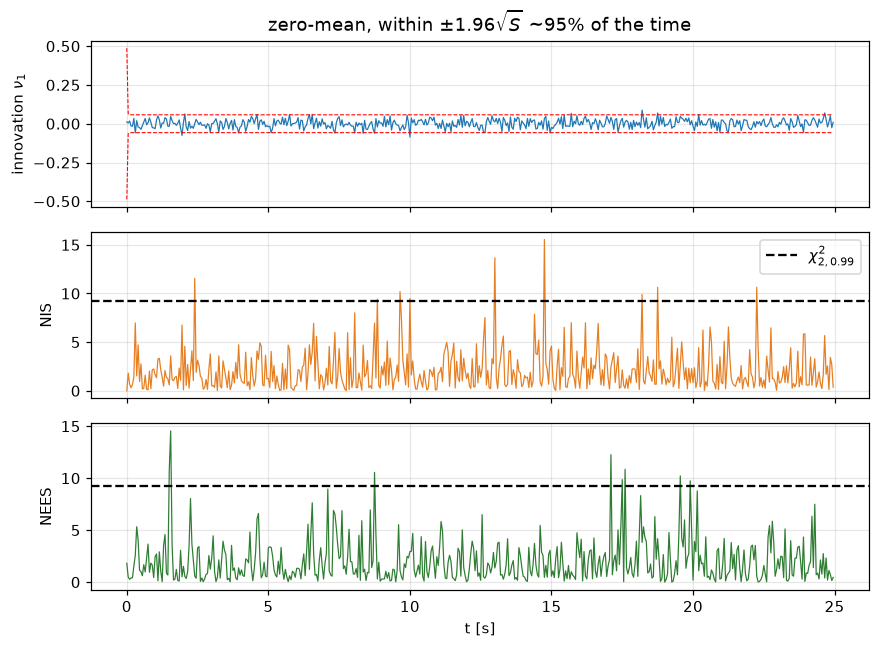

fraction of NIS above the 99% gate: 0.02  (expected ~0.01)


In [2]:
# Demo A: the filter is consistent under the correct model
t = np.arange(len(H0["nis"]))*Ts
fig, ax = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
ax[0].plot(t, H0["nu0"], color="#1f77b4", lw=.8)
ax[0].plot(t,  1.96*np.sqrt(H0["s0"]), 'r--', lw=.7); ax[0].plot(t, -1.96*np.sqrt(H0["s0"]), 'r--', lw=.7)
ax[0].set_ylabel("innovation $\\nu_1$"); ax[0].set_title("zero-mean, within $\\pm1.96\\sqrt{S}$ ~95% of the time")
ax[1].plot(t, H0["nis"], color="#e67e22", lw=.8); ax[1].axhline(9.21, ls="--", color="k", label="$\\chi^2_{2,0.99}$")
ax[1].set_ylabel("NIS"); ax[1].legend(loc="upper right")
ax[2].plot(t, H0["nees"], color="#2e7d32", lw=.8); ax[2].axhline(9.21, ls="--", color="k")
ax[2].set_ylabel("NEES"); ax[2].set_xlabel("t [s]")
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("fraction of NIS above the 99%% gate: %.2f  (expected ~0.01)" % np.mean(H0["nis"] > 9.21))

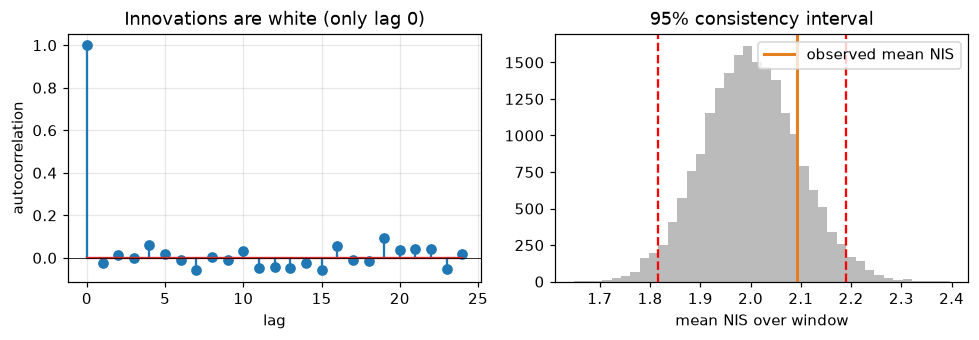

time-averaged NIS  = 2.09   95% acceptance interval [1.82, 2.19]
time-averaged NEES = 1.99   -> filter covariance P is honest


In [3]:
# Whiteness of the innovations, and the time-averaged consistency test (Monte-Carlo bounds)
def autocorr(x, maxlag=25):
    x = x - x.mean(); c = np.correlate(x, x, "full"); c = c[c.size//2:]
    return c[:maxlag] / c[0]

warm = 50; m = 2                                   # skip filter warm-up
avg_nis = H0["nis"][warm:].mean(); avg_nees = H0["nees"][warm:].mean()
Nw = len(H0["nis"]) - warm
mc = np.mean(rng.chisquare(m, size=(20000, Nw)), axis=1)   # sampling dist. of the mean
lo, hi = np.percentile(mc, [2.5, 97.5])

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].stem(range(25), autocorr(H0["nu0"]))
ax[0].axhline(0, color='k', lw=.5); ax[0].set(xlabel="lag", ylabel="autocorrelation",
    title="Innovations are white (only lag 0)")
ax[0].grid(alpha=.3)
ax[1].hist(mc, bins=40, color="#bbb"); ax[1].axvline(lo, color='r', ls='--'); ax[1].axvline(hi, color='r', ls='--')
ax[1].axvline(avg_nis, color="#e67e22", lw=2, label="observed mean NIS")
ax[1].set(xlabel="mean NIS over window", title="95% consistency interval"); ax[1].legend()
plt.tight_layout(); plt.show()
print("time-averaged NIS  = %.2f   95%% acceptance interval [%.2f, %.2f]" % (avg_nis, lo, hi))
print("time-averaged NEES = %.2f   -> filter covariance P is honest" % avg_nees)

## 5. From consistency to fault detection

Because NIS tests the innovation against the model, anything that breaks the model
raises it: a bias, an unmodelled manoeuvre, a wrong noise covariance, or an
**out-of-distribution regime** the perception was never trained on. The classical
theory of innovation-based fault detection [7,8] formalises this; a validation gate
on NIS also rejects outliers in measurement association [6].

The case that matters for us: the perception network becomes *confidently wrong*.
The measurement $y_k$ acquires a systematic bias, but the network keeps reporting a
small $R$. The innovation $\nu_k$ then grows while $S_k$ stays small, so
$\mathrm{NIS}=\nu^\top S^{-1}\nu$ explodes - the failure is detected even though the
perception's own uncertainty never rose. This is precisely the gap that notebook 04
warned about.

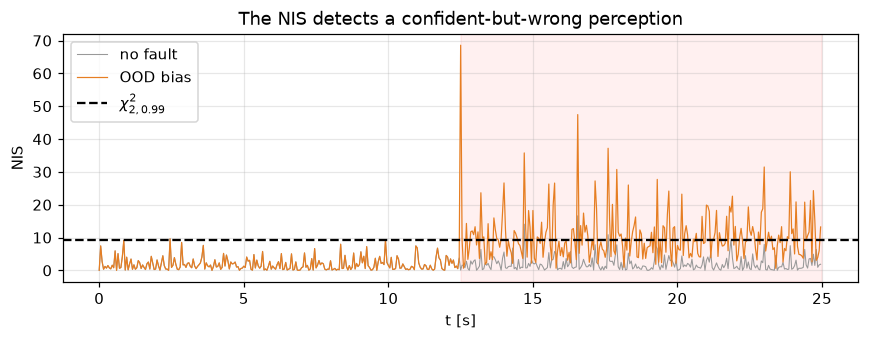

mean NIS  before bias: 1.9    after bias: 10.5
detection rate after bias (NIS>9.21): 47%


In [4]:
# Demo B: an out-of-distribution bias appears at t = 12.5 s; reported R stays small
fault = run_filter(N=500, bias_after=250, bias=(0.22, 0.06), seed=2)
t = np.arange(500)*Ts
plt.figure(figsize=(8, 3.2))
plt.plot(t, run_filter(N=500, seed=2)["nis"], color="#999", lw=.7, label="no fault")
plt.plot(t, fault["nis"], color="#e67e22", lw=.8, label="OOD bias")
plt.axhline(9.21, ls="--", color="k", label="$\\chi^2_{2,0.99}$")
plt.axvspan(250*Ts, 500*Ts, color="red", alpha=.06)
plt.ylabel("NIS"); plt.xlabel("t [s]"); plt.title("The NIS detects a confident-but-wrong perception")
plt.legend(loc="upper left"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("mean NIS  before bias: %.1f    after bias: %.1f" % (fault["nis"][:250].mean(), fault["nis"][250:].mean()))
print("detection rate after bias (NIS>9.21): %.0f%%" % (100*np.mean(fault["nis"][250:] > 9.21)))

In [5]:
# Why an *honest* R matters: the test compares the innovation to the CLAIMED S
print("claimed-R scale   mean NIS   interpretation")
for scale in (0.25, 0.5, 1.0, 2.0, 4.0):
    mn = run_filter(N=500, R_scale=scale, seed=3)["nis"][50:].mean()
    tag = ("overconfident R -> false alarms" if scale < 1 else
           "honest R -> mean ~ 2" if scale == 1 else
           "conservative R -> misses faults")
    print("   %5.2f          %6.2f    %s" % (scale, mn, tag))

claimed-R scale   mean NIS   interpretation
    0.25            4.06    overconfident R -> false alarms
    0.50            2.89    overconfident R -> false alarms
    1.00            1.93    honest R -> mean ~ 2
    2.00            1.24    conservative R -> misses faults
    4.00            0.79    conservative R -> misses faults


## 6. Where this plugs in

The NIS is the second of the three signals fused into the integrity score of
notebook 06: $s_{NIS}=\exp\!\big(-(\mathrm{NIS}-\chi^2)^+/c\big)$ is near $1$ while
the filter is consistent and decays once NIS crosses the threshold. Unlike the
perception's self-reported uncertainty (notebook 04) and the pixel-level ODD
features (notebook 03), the NIS is an *external* check grounded in the vehicle
dynamics - which is why it catches the out-of-distribution curve the others miss.

### Exercises

1. Confirm $\mathbb E[\mathrm{NIS}]=m$ and $\mathbb E[\mathrm{NEES}]=n$ empirically by
   averaging over many independent runs, and check the variance matches $2m$, $2n$.
2. Make the true process noise larger than the filter's $Q$ (an under-modelled
   manoeuvre). Which statistic reacts - NIS, NEES, or both?
3. Replace the step bias with a slow ramp and compare single-sample gating against a
   windowed average. Which detects the gradual drift sooner? (Foreshadows CUSUM in notebook 09.)
4. Add a whiteness test: compute the lag-1 innovation autocorrelation under H0 and
   under the bias. Does a constant bias break whiteness, or only zero-mean?

## References

1. R. E. Kalman. *A New Approach to Linear Filtering and Prediction Problems.* ASME Journal of Basic Engineering, 82(1):35-45, 1960. doi:10.1115/1.3662552
2. A. H. Jazwinski. *Stochastic Processes and Filtering Theory.* Academic Press, 1970.
3. B. D. O. Anderson, J. B. Moore. *Optimal Filtering.* Prentice Hall, 1979.
4. S. Sarkka. *Bayesian Filtering and Smoothing.* Cambridge University Press, 2013.
5. T. Kailath. *An innovations approach to least-squares estimation - Part I: Linear filtering in additive white noise.* IEEE Transactions on Automatic Control, 13(6):646-655, 1968. doi:10.1109/TAC.1968.1099025
6. Y. Bar-Shalom, X.-R. Li, T. Kirubarajan. *Estimation with Applications to Tracking and Navigation.* Wiley, 2001. (NIS / NEES consistency tests and validation gating.)
7. R. K. Mehra, J. Peschon. *An innovations approach to fault detection and diagnosis in dynamic systems.* Automatica, 7(5):637-640, 1971. doi:10.1016/0005-1098(71)90028-8
8. A. S. Willsky. *A survey of design methods for failure detection in dynamic systems.* Automatica, 12(6):601-611, 1976. doi:10.1016/0005-1098(76)90041-8
9. R. G. Brown, P. Y. C. Hwang. *Introduction to Random Signals and Applied Kalman Filtering,* 4th ed. Wiley, 2012. (Integrity monitoring context.)